In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import os

from network import *
from utils import *

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', data_home='../mnist_data/', as_frame=False, parser='liac-arff')
X_data = mnist.data / 255.0
y_labels = mnist.target.astype(int)

In [3]:
NUM_TRAIN_IMAGES = 1000
X_train = X_data[:NUM_TRAIN_IMAGES]
y_train = y_labels[:NUM_TRAIN_IMAGES]

EPOCHS = 3
X_train_epochs = np.tile(X_train, (EPOCHS, 1))
y_train_epochs = np.tile(y_train, EPOCHS)

image_stream = TimedArray(X_train_epochs, dt=presentation_time)

In [4]:
N_outputs = 400
lr = 0.1   #learning rate
net, InputLayer, FeedForward, OutputLayer, spike_mon = build_network_train(N_outputs, lr)

In [5]:
save_path = f'../trained_model/{N_outputs}/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

Starting simulation at t=0. s for a duration of 0.35 ks
78.1 s (22%) simulated in 1m 0s, estimated 3m 29s remaining.
142.0015 s (40%) simulated in 2m 0s, estimated 2m 56s remaining.
205.1145 s (58%) simulated in 3m 0s, estimated 2m 7s remaining.
269.2835 s (76%) simulated in 4m 0s, estimated 1m 12s remaining.
0.33583 ks (95%) simulated in 5m 0s, estimated 13s remaining.
0.35 ks (100%) simulated in 5m 12s
Successfully saved weights to ../trained_model/400/


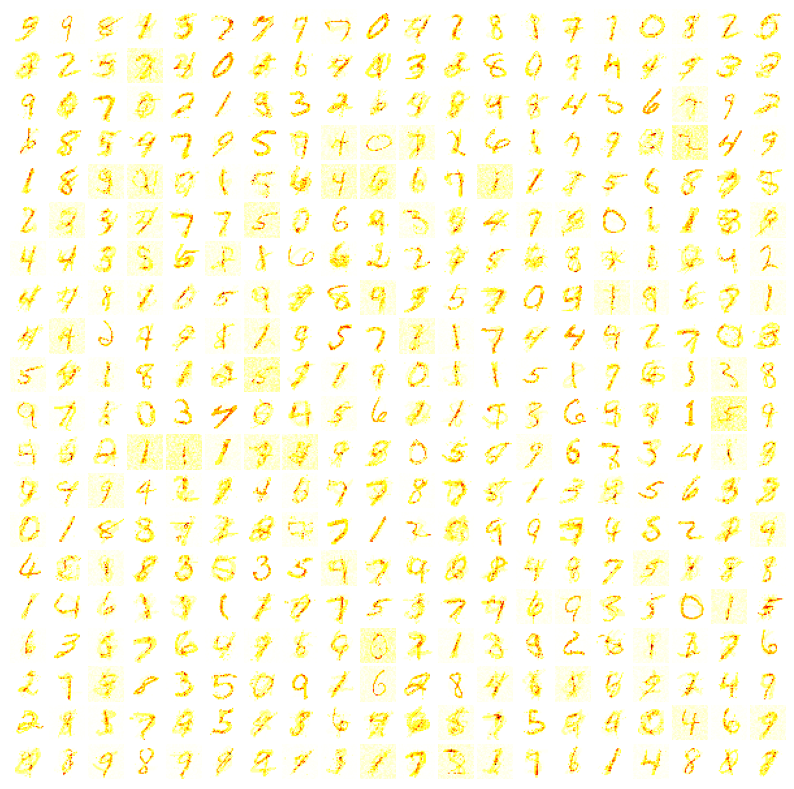

Starting simulation at t=0.35 ks for a duration of 0.35 ks
62.1445 s (17%) simulated in 1m 0s, estimated 4m 38s remaining.
125.32 s (35%) simulated in 2m 0s, estimated 3m 35s remaining.
191.517 s (54%) simulated in 3m 0s, estimated 2m 29s remaining.
257.435 s (73%) simulated in 4m 0s, estimated 1m 26s remaining.
0.321198 ks (91%) simulated in 5m 0s, estimated 27s remaining.
0.35 ks (100%) simulated in 5m 22s
Successfully saved weights to ../trained_model/400/


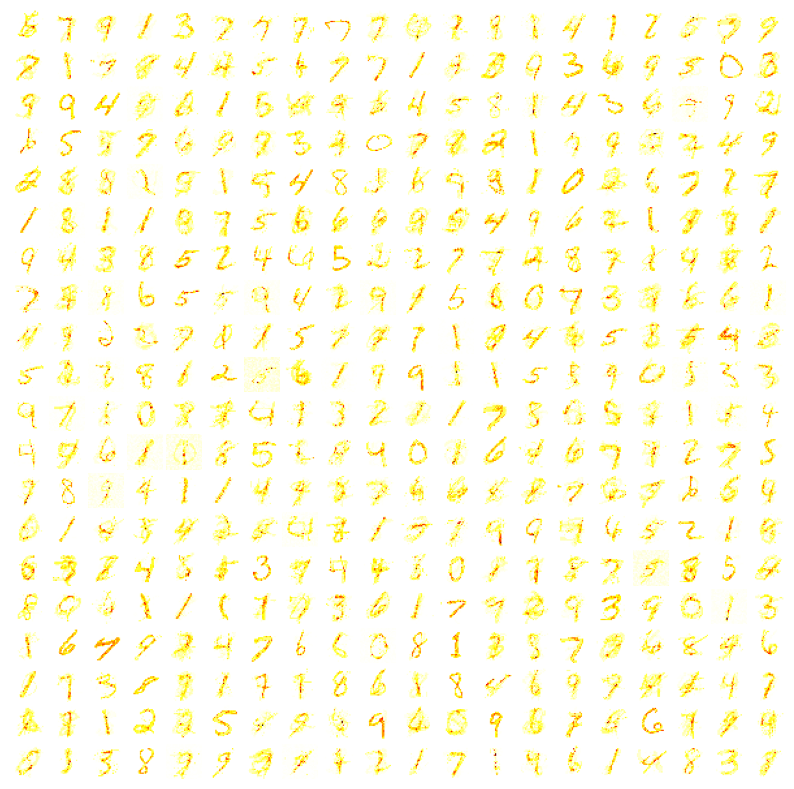

Starting simulation at t=0.7 ks for a duration of 0.35 ks
63.2725 s (18%) simulated in 1m 0s, estimated 4m 32s remaining.
117.9715 s (33%) simulated in 2m 0s, estimated 3m 56s remaining.
167.413 s (47%) simulated in 3m 0s, estimated 3m 16s remaining.
228.9035 s (65%) simulated in 4m 0s, estimated 2m 7s remaining.
288.4145 s (82%) simulated in 5m 0s, estimated 1m 4s remaining.
0.35 ks (100%) simulated in 5m 59s
Successfully saved weights to ../trained_model/400/


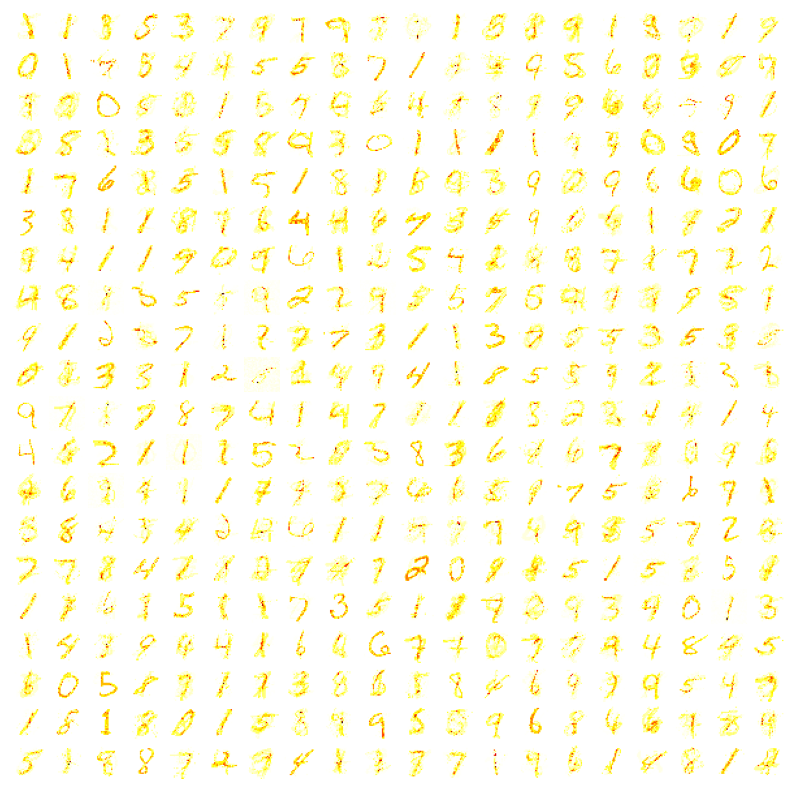

In [6]:
time_per_epoch = presentation_time * NUM_TRAIN_IMAGES
total_training_time = presentation_time * NUM_TRAIN_IMAGES * EPOCHS

for epoch in range(EPOCHS):
    net.run(time_per_epoch, report='text', report_period=1800*second)
    current_weights = np.array(FeedForward.w)
    np.save(os.path.join(save_path, f'weights_epoch_{epoch + 1}.npy'), current_weights)
    print(f"Successfully saved weights to {save_path}")
    final_weights = get_2d_weights(net['feed_forward'], 28*28, N_outputs)
    plot_weights(final_weights, N_outputs)

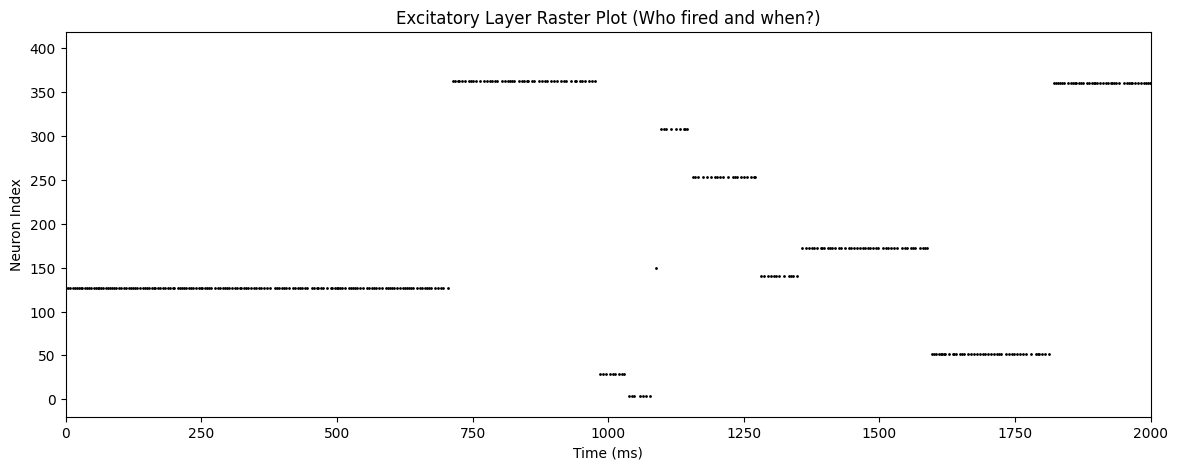

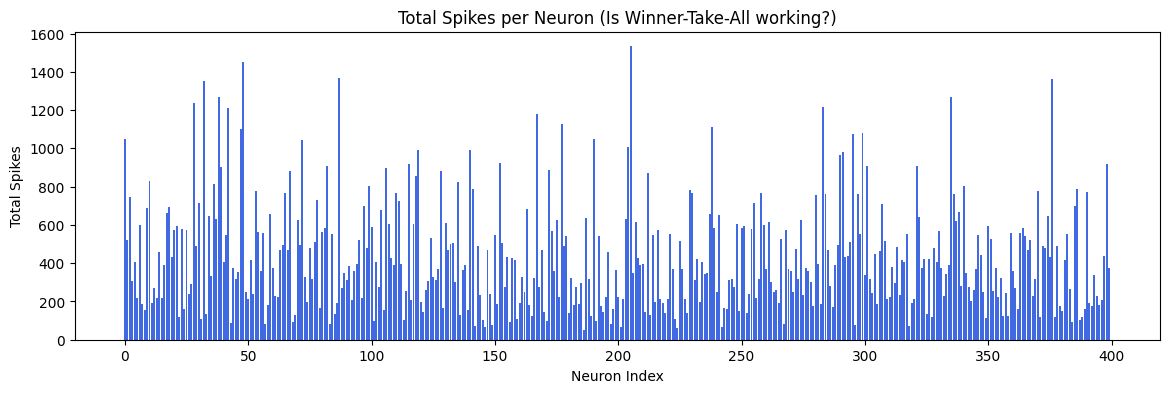

In [7]:
show_spikes(spike_mon, a=0, b=2000)